# ResearchLanka Slide Chart Images

Run this notebook from the repository root. It reads `frontend/src/data/datasetCharts.json` and writes slide-ready PNG images to `slide_images/`.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


def find_repo_root(start=Path.cwd()):
    start = Path(start).resolve()
    for path in [start, *start.parents]:
        if (path / "frontend/src/data/datasetCharts.json").exists():
            return path
    raise FileNotFoundError("Could not find frontend/src/data/datasetCharts.json from this notebook location.")

REPO_ROOT = find_repo_root()
DATA_PATH = REPO_ROOT / "frontend/src/data/datasetCharts.json"
OUT_DIR = REPO_ROOT / "slide_images"
OUT_DIR.mkdir(exist_ok=True)

with DATA_PATH.open("r", encoding="utf-8") as f:
    charts = json.load(f)

plt.rcParams.update({
    "figure.dpi": 160,
    "savefig.dpi": 300,
    "font.size": 11,
    "axes.titlesize": 16,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

charts.keys()

dict_keys(['yearWindow', 'publicationsByYear', 'mainSources', 'multiSourceCombinations', 'deduplication', 'modelComparison'])

In [2]:
def save_bar_chart(data, title, filename, xlabel="Records", horizontal=True, top_n=None, min_year=None):
    df = pd.DataFrame(data).copy()

    if min_year is not None:
        df = df[df["label"].astype(int) >= min_year]

    if top_n is not None:
        df = df.sort_values("value", ascending=False).head(top_n)

    if horizontal:
        df = df.sort_values("value", ascending=True)
        fig, ax = plt.subplots(figsize=(11, max(4.5, len(df) * 0.42)))
        bars = ax.barh(df["label"], df["value"], color="#2563eb")
        ax.set_xlabel(xlabel)
        for bar in bars:
            width = bar.get_width()
            ax.text(width, bar.get_y() + bar.get_height() / 2, f" {int(width):,}", va="center", fontsize=9)
    else:
        fig, ax = plt.subplots(figsize=(13, 5.5))
        bars = ax.bar(df["label"], df["value"], color="#2563eb")
        ax.set_ylabel(xlabel)
        ax.tick_params(axis="x", rotation=45)
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width() / 2, height, f"{int(height):,}", ha="center", va="bottom", fontsize=8, rotation=90)

    ax.set_title(title, weight="bold", pad=14)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="x" if horizontal else "y", alpha=0.25)
    fig.tight_layout()

    output = OUT_DIR / filename
    fig.savefig(output, bbox_inches="tight", facecolor="white")
    plt.show()
    return output

## Publications By Year

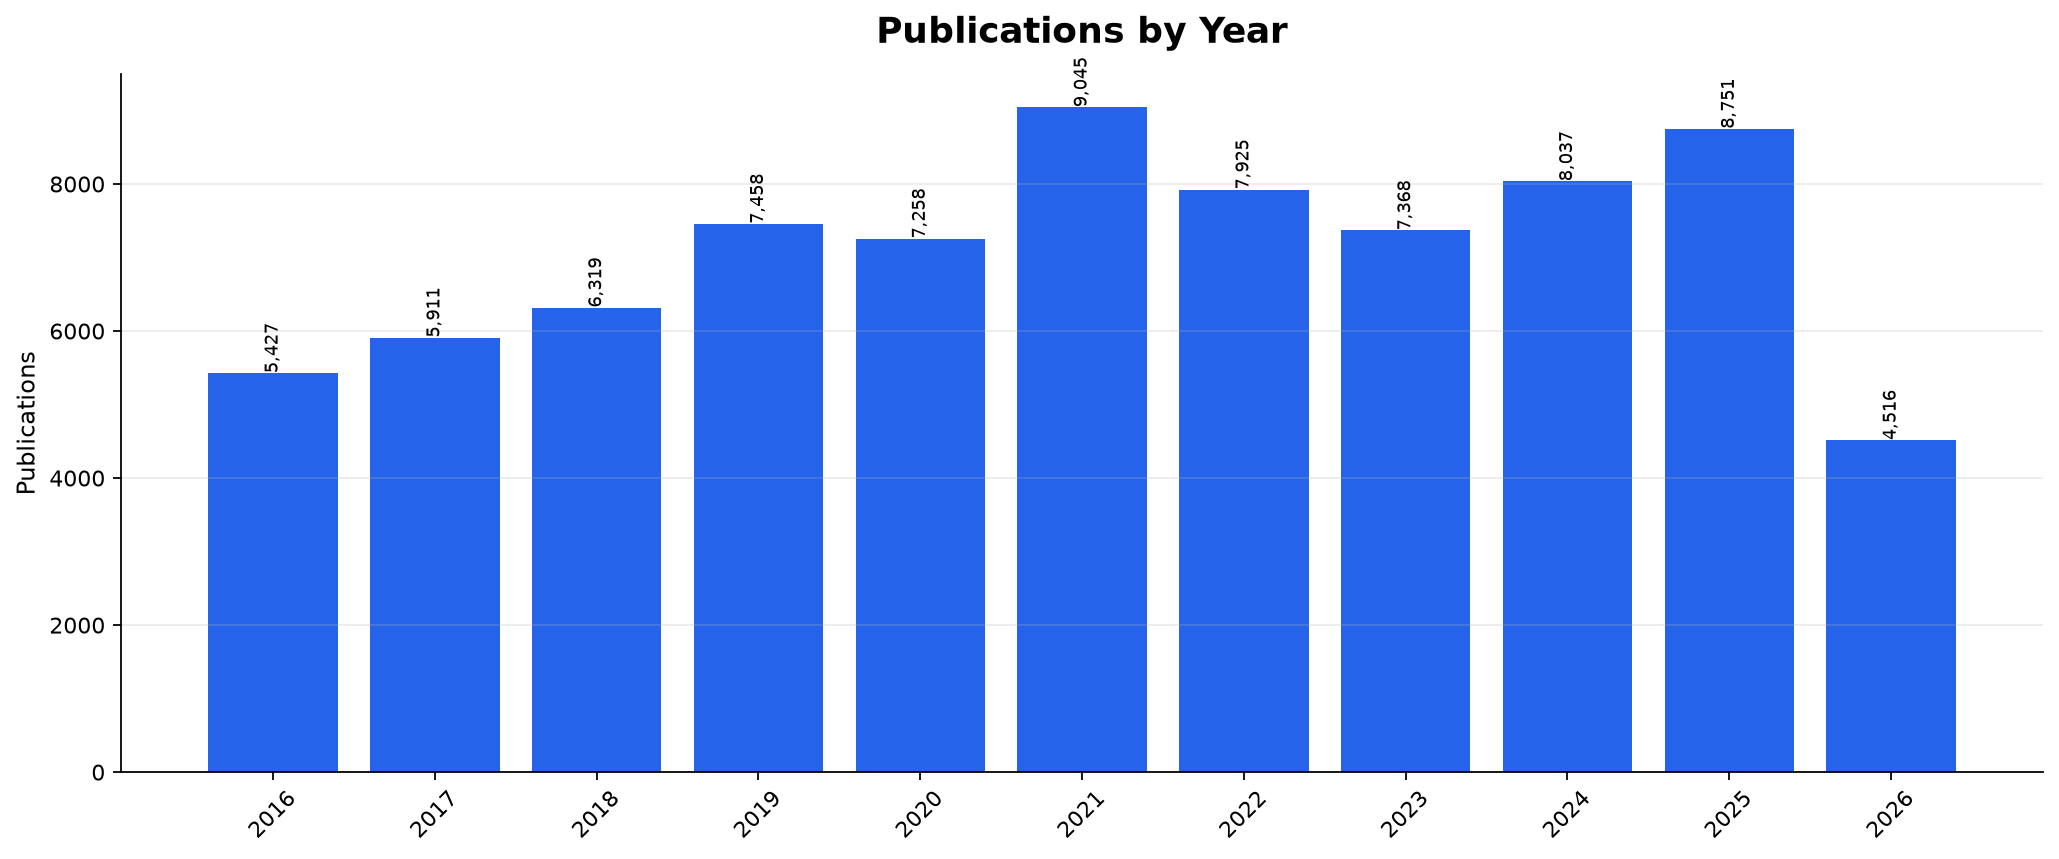

PosixPath('/home/anusankrishnathas/Desktop/researchlanka-ai/researchlanka-ai/slide_images/publications_by_year.png')

In [3]:
save_bar_chart(
    charts["publicationsByYear"],
    title="Publications by Year",
    filename="publications_by_year.png",
    xlabel="Publications",
    horizontal=False,
    min_year=2016,
)

## Records Collected From Main Sources

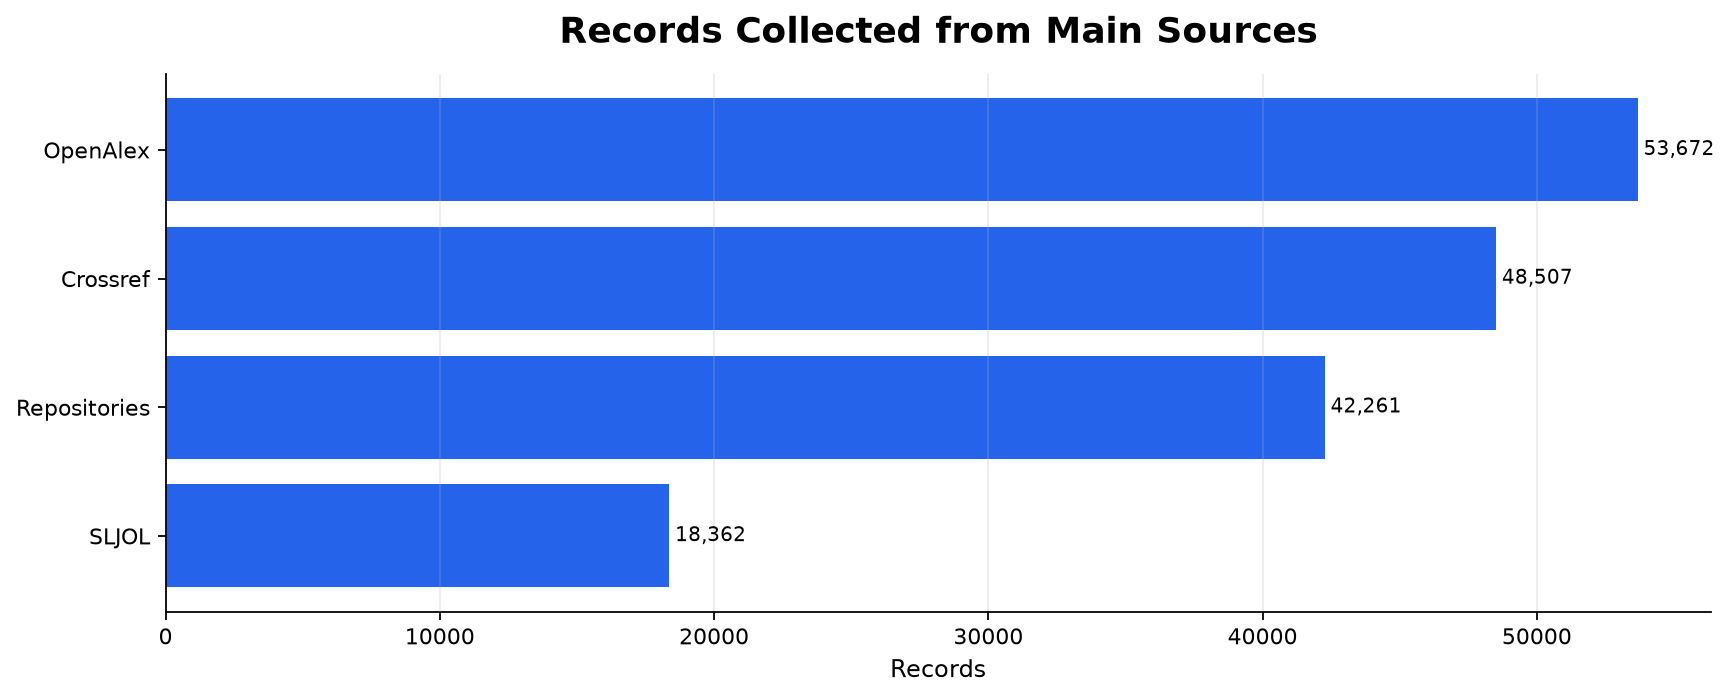

PosixPath('/home/anusankrishnathas/Desktop/researchlanka-ai/researchlanka-ai/slide_images/main_sources_horizontal.png')

In [4]:
save_bar_chart(
    charts["mainSources"],
    title="Records Collected from Main Sources",
    filename="main_sources_horizontal.png",
    xlabel="Records",
    horizontal=True,
)

## Multi-source Comparison

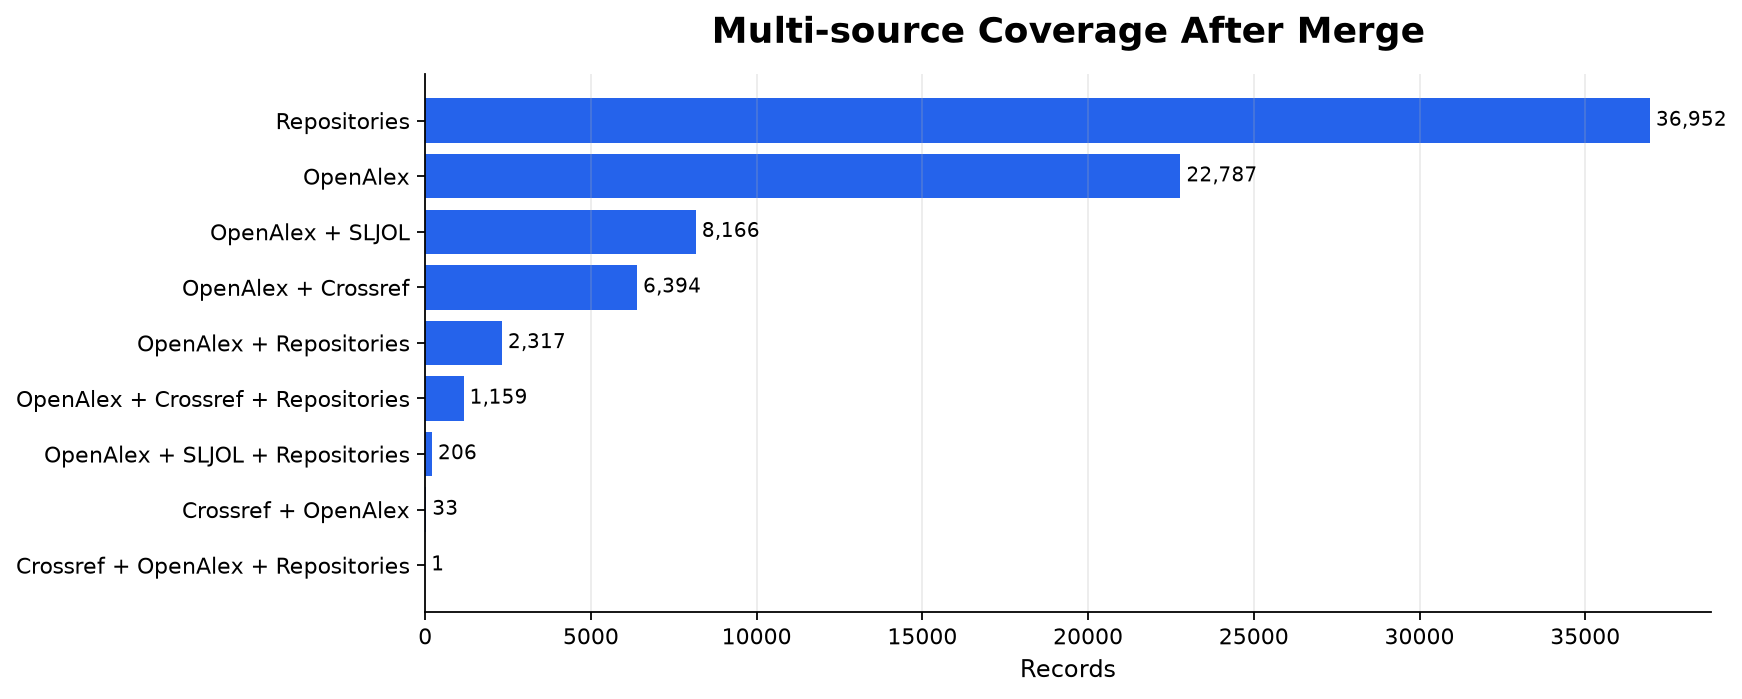

PosixPath('/home/anusankrishnathas/Desktop/researchlanka-ai/researchlanka-ai/slide_images/multi_source_comparison_horizontal.png')

In [5]:
save_bar_chart(
    charts["multiSourceCombinations"],
    title="Multi-source Coverage After Merge",
    filename="multi_source_comparison_horizontal.png",
    xlabel="Records",
    horizontal=True,
)

## Deduplication Review Signals

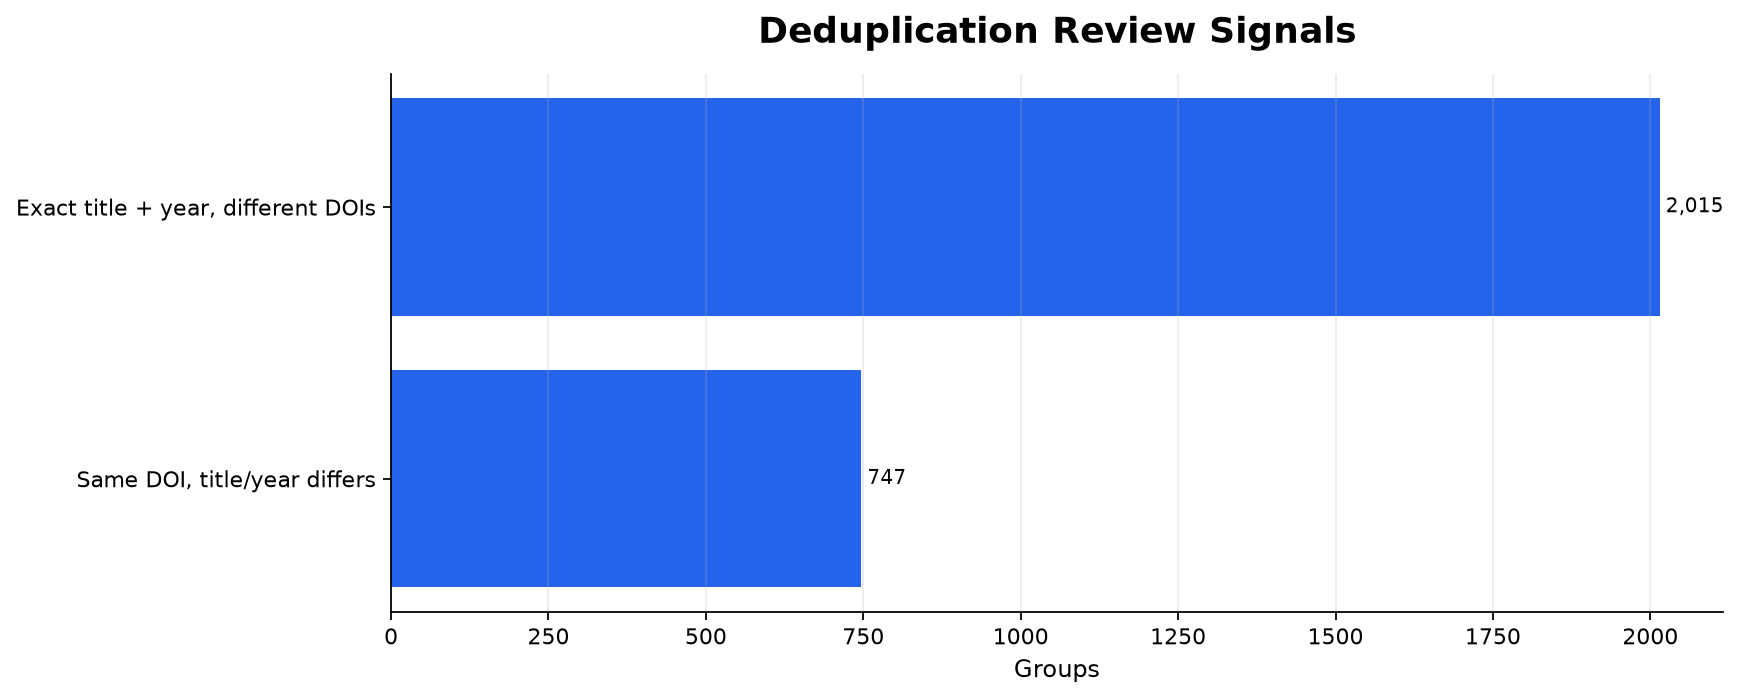

PosixPath('/home/anusankrishnathas/Desktop/researchlanka-ai/researchlanka-ai/slide_images/deduplication_review_signals.png')

In [6]:
save_bar_chart(
    charts["deduplication"],
    title="Deduplication Review Signals",
    filename="deduplication_review_signals.png",
    xlabel="Groups",
    horizontal=True,
)

## Model Comparison

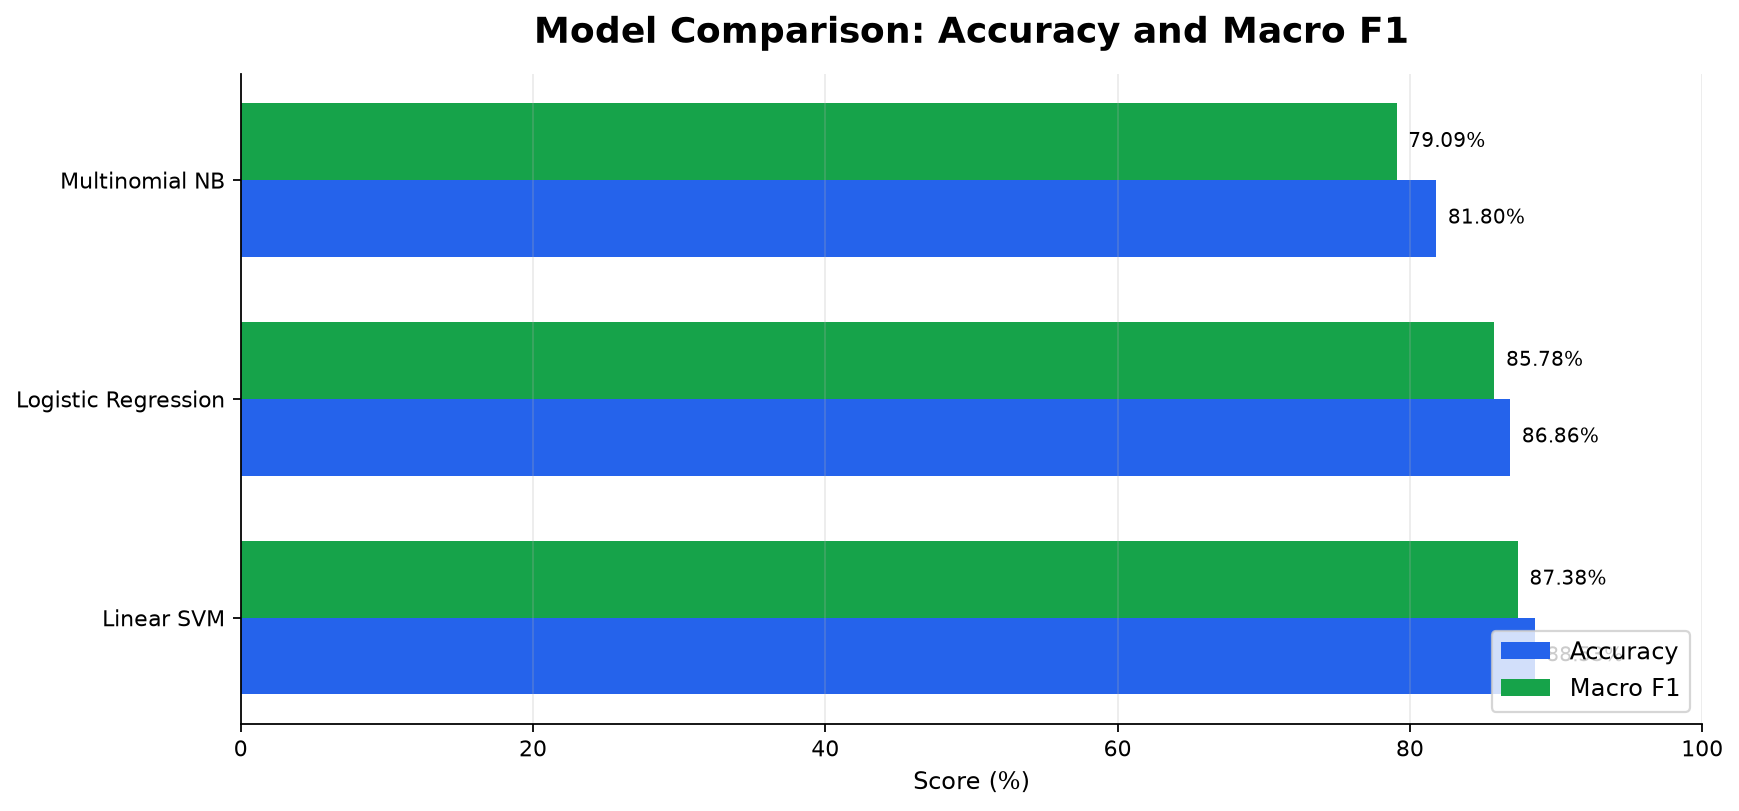

PosixPath('/home/anusankrishnathas/Desktop/researchlanka-ai/researchlanka-ai/slide_images/model_comparison_accuracy_f1.png')

In [7]:
model_df = pd.DataFrame(charts["modelComparison"])

fig, ax = plt.subplots(figsize=(11, 5.2))
y = range(len(model_df))
bar_h = 0.35

ax.barh([i - bar_h / 2 for i in y], model_df["accuracy"], height=bar_h, label="Accuracy", color="#2563eb")
ax.barh([i + bar_h / 2 for i in y], model_df["macroF1"], height=bar_h, label="Macro F1", color="#16a34a")

ax.set_yticks(list(y))
ax.set_yticklabels(model_df["label"])
ax.set_xlabel("Score (%)")
ax.set_xlim(0, 100)
ax.set_title("Model Comparison: Accuracy and Macro F1", weight="bold", pad=14)

for i, row in model_df.iterrows():
    ax.text(row["accuracy"] + 0.8, i - bar_h / 2, f"{row['accuracy']:.2f}%", va="center", fontsize=9)
    ax.text(row["macroF1"] + 0.8, i + bar_h / 2, f"{row['macroF1']:.2f}%", va="center", fontsize=9)

ax.legend(loc="lower right")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="x", alpha=0.25)
fig.tight_layout()

output = OUT_DIR / "model_comparison_accuracy_f1.png"
fig.savefig(output, bbox_inches="tight", facecolor="white")
plt.show()
output

## Generated Files

In [8]:
sorted(OUT_DIR.glob("*.png"))

[PosixPath('/home/anusankrishnathas/Desktop/researchlanka-ai/researchlanka-ai/slide_images/deduplication_review_signals.png'),
 PosixPath('/home/anusankrishnathas/Desktop/researchlanka-ai/researchlanka-ai/slide_images/main_sources_horizontal.png'),
 PosixPath('/home/anusankrishnathas/Desktop/researchlanka-ai/researchlanka-ai/slide_images/model_comparison_accuracy_f1.png'),
 PosixPath('/home/anusankrishnathas/Desktop/researchlanka-ai/researchlanka-ai/slide_images/multi_source_comparison_horizontal.png'),
 PosixPath('/home/anusankrishnathas/Desktop/researchlanka-ai/researchlanka-ai/slide_images/publications_by_year.png')]